# General introduction
## Idea
Use CGP to construct more complex features $X'$ and use them to predict a $y$ target rather than the raw $X$.

## Problems considered
Same as PPSN paper on constants optimization.
| Dataset | Samples | Features | Train | Test |
| --- | --- | --- | --- | --- |
| Chemical Competition | 1066 | 57 | 710  | 356   | `
| Chemical Tower       | 4999 | 25 | 3135 | 1864  |
| Friction Dynamic     | 2017 | 17 | 1008 | 1009  |
| Friction Static      | 2017 | 16 | 1008 | 1009  |
| NASA Battery 1       | 635  | 6  | 503  | 132   |
| NASA Battery 2       | 1638 | 5  | 1099 | 539   |
| Flow Stress          | 7800 | 2  | 4199 | 3601  |
| Nikuradse 1          | 361  | 2  | 229  | 132   | 
| Nikuradse 2          | 362  | 1  | 199  | 163   |

## Baselines
- Operon (SOTA on symbolic regression) $\rightarrow$ `Operon`
- Ridge regression from $X$ to $y$ $\rightarrow$ `ridge`
- Tree GP (tinygp version) $\rightarrow$ `tinygp`

## CGP versions considered
- Standard CGP (from $X$ to $y$) $\rightarrow$ `standard`
- CGP with linear scaling (from $X$ to $y$) $\rightarrow$ `linscal`
- CGP used for feature construction ($X$ to $X'$) followed by Ridge regression ($X'$ to $y$) $\rightarrow$ `feats`
- As previous, with addition of bias term in Ridge regression $\rightarrow$ `featsls`
- CGP used for feature construction ($X$ to $X'$) followed by another CGP for regression ($X'$ to $y$) $\rightarrow$ `seq`

For `standard`, `linscal`, `feats`, and `featsls` experimented with both 50 and 100 nodes (when not specified it is 50) for the CGP part.
For `seq` experimented with 50 nodes for each part of the pipeline.

## Number of features
By default, the number of intermediate features $|X'|$ is set by default to round$(\sqrt{|X|})$.
For the Chemical Competition problem also studied the impact of features numbers.

In [27]:
from copy import copy
import scikit_posthocs as sp

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

sns.set_theme()
warnings.filterwarnings('ignore')

In [28]:
baselines_df1 = pd.read_csv("baselines.csv")
baselines_df2 = pd.read_csv("baselines_tinygp.csv")
baselines_df = pd.concat([baselines_df1, baselines_df2], ignore_index=True)

In [29]:
problems = ["chemical_2_competition", "chemical_1_tower", "friction_dyn_one-hot", "friction_stat_one-hot",
            "nasa_battery_1_10min", "nasa_battery_2_20min", "flow_stress_phip0.1", "nikuradse_1",
            "nikuradse_2", ]

# Performance

In [102]:
dfs = []
missing = 0
missing_configs = []
for problem in problems:
    tmp_df = pd.read_csv(f"../results/ridge_{problem}.csv")
    tmp_df["seed"] = 0
    tmp_df["problem"] = problem
    tmp_df["algo"] = "ridge"
    tmp_df["method"] = "baseline"
    tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
    dfs.append(tmp_df)
    for seed in range(30):
        for method in ["CGP", "CGP_100"]:
            for extra in ['linscal', 'feats', 'featsls', 'baseline', 'seq']:
                if os.path.exists(f"../results/{method}_{extra}_{problem}_{seed}.pickle"):
                    tmp_df = pd.read_csv(f"../results/{method}_{extra}_{problem}_{seed}.csv")
                    tmp_df["seed"] = seed
                    tmp_df["problem"] = problem
                    tmp_df["algo"] = extra.replace("baseline", "standard")
                    tmp_df["method"] = method
                    tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
                    dfs.append(tmp_df)
df = pd.concat(dfs, ignore_index=True)
df["test_accuracy"] = df["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(float)
df.head()

,iteration,max_fitness,time,test_accuracy,seed,problem,algo,method,total_time
0,1499,-0.921519,0.000000,-1.450991,0,chemical_2_competition,ridge,baseline,0
1,0,0.460991,0.000000,-0.077899,0,chemical_2_competition,linscal,CGP,0
2,1,0.460991,3.244850,-0.077898,0,chemical_2_competition,linscal,CGP,3
3,2,0.460991,0.866934,-0.077898,0,chemical_2_competition,linscal,CGP,4
4,3,0.460991,0.885998,-0.077898,0,chemical_2_competition,linscal,CGP,4


In [103]:
baselines_list = ["Operon", "tinygp"]  # "QLattice", "PySR", "eggp"]
# baselines_list = ["Operon"]
baselines_df1 = pd.read_csv("baselines.csv")
baselines_df2 = pd.read_csv("baselines_tinygp.csv")
baselines_df = pd.concat([baselines_df1, baselines_df2], ignore_index=True)
baselines_df.rename(columns={
    "run": "seed",
    "algorithm": "algo",
    "r2_test": "accuracy",
    "dataset": "problem",
}, inplace=True)
baselines_df = baselines_df[["seed", "algo", "accuracy", "problem"]]
baselines_df = baselines_df[baselines_df["algo"].isin(baselines_list)]
baselines_df = baselines_df[baselines_df["problem"].isin(problems)]
baselines_df["method"] = "baseline"
baselines_df.head()

,seed,algo,accuracy,problem,method
4756,0,Operon,0.917246,chemical_1_tower,baseline
4757,1,Operon,0.915317,chemical_1_tower,baseline
4758,2,Operon,0.911019,chemical_1_tower,baseline
4759,3,Operon,0.914184,chemical_1_tower,baseline
4760,4,Operon,0.912897,chemical_1_tower,baseline


In [104]:
df1 = copy(df)
df2 = copy(df)
df1 = df.rename(columns={"test_accuracy": "accuracy"})
df2 = df.rename(columns={"max_fitness": "accuracy"})
df1 = df1.drop(columns=["max_fitness"])
df2 = df2.drop(columns=["test_accuracy"])
df1["when"] = "test"
df2["when"] = "train"
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,iteration,time,accuracy,seed,problem,algo,method,total_time,when
0,1499,0.000000,-1.450991,0,chemical_2_competition,ridge,baseline,0,test
1,0,0.000000,-0.077899,0,chemical_2_competition,linscal,CGP,0,test
2,1,3.244850,-0.077898,0,chemical_2_competition,linscal,CGP,3,test
3,2,0.866934,-0.077898,0,chemical_2_competition,linscal,CGP,4,test
4,3,0.885998,-0.077898,0,chemical_2_competition,linscal,CGP,4,test


In [105]:
max_iter = df.groupby(["algo", "problem"])["iteration"].transform("max")
final_df = df[df["iteration"] == max_iter].reset_index(drop=True)
final_df.head()

,iteration,time,accuracy,seed,problem,algo,method,total_time,when
0,1499,0.000000,-1.450991,0,chemical_2_competition,ridge,baseline,0,test
1,1499,0.888314,0.606357,0,chemical_2_competition,linscal,CGP,1344,test
2,1499,0.890822,0.641150,0,chemical_2_competition,feats,CGP,1335,test
3,1499,0.890691,0.861131,0,chemical_2_competition,featsls,CGP,1429,test
4,1499,0.847909,-0.016208,0,chemical_2_competition,standard,CGP,1201,test


In [106]:
final_df_for_baseline_merge = final_df[final_df["when"] == "test"][["seed", "algo", "method", "problem", "accuracy"]]
baselines_df_filtered = baselines_df[baselines_df["problem"].isin(final_df_for_baseline_merge["problem"])]
final_df_and_baseline = pd.concat([final_df_for_baseline_merge, baselines_df_filtered], ignore_index=True)
final_df_and_baseline.head()

,seed,algo,method,problem,accuracy
0,0,ridge,baseline,chemical_2_competition,-1.450991
1,0,linscal,CGP,chemical_2_competition,0.606357
2,0,feats,CGP,chemical_2_competition,0.641150
3,0,featsls,CGP,chemical_2_competition,0.861131
4,0,standard,CGP,chemical_2_competition,-0.016208


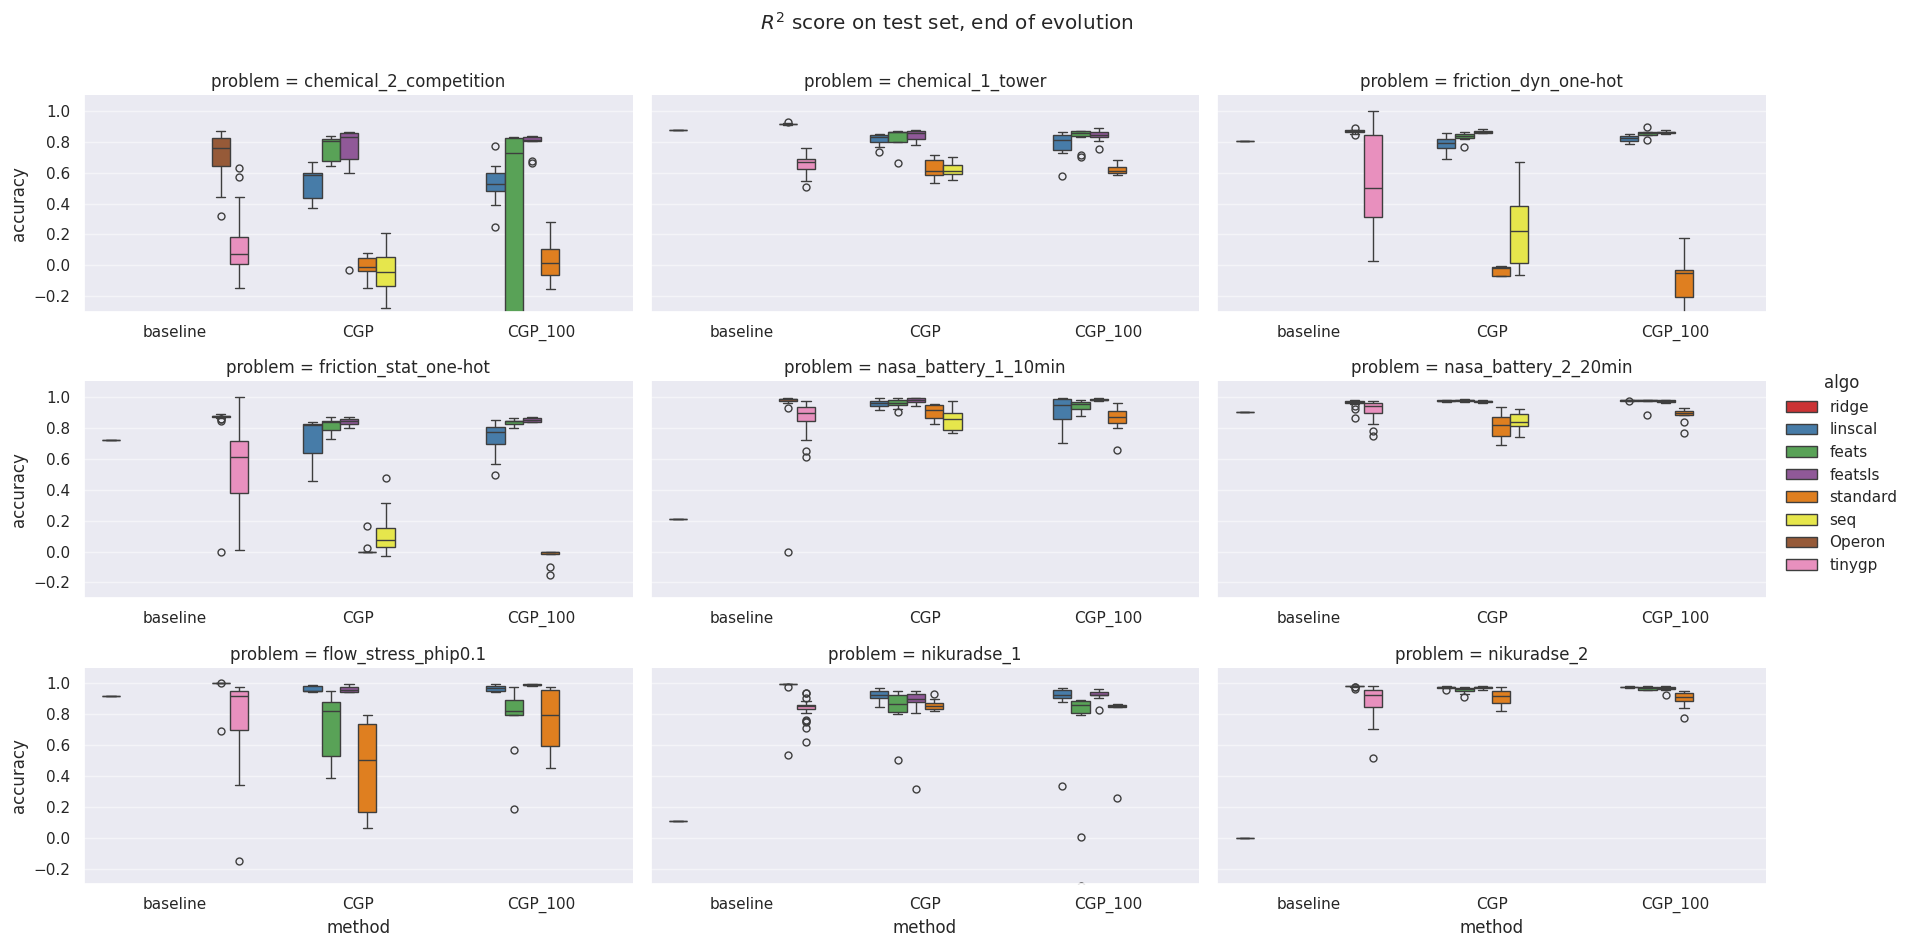

In [107]:
g = sns.catplot(x="method", y="accuracy", hue="algo", data=final_df_and_baseline, col="problem", col_wrap=3,
                kind="box", palette="Set1", height=3, aspect=2, sharex=False)
g.figure.suptitle("$R^2$ score on test set, end of evolution", y=1.05)  # Add title above the plot
plt.ylim(-.3, 1.1)
plt.show()

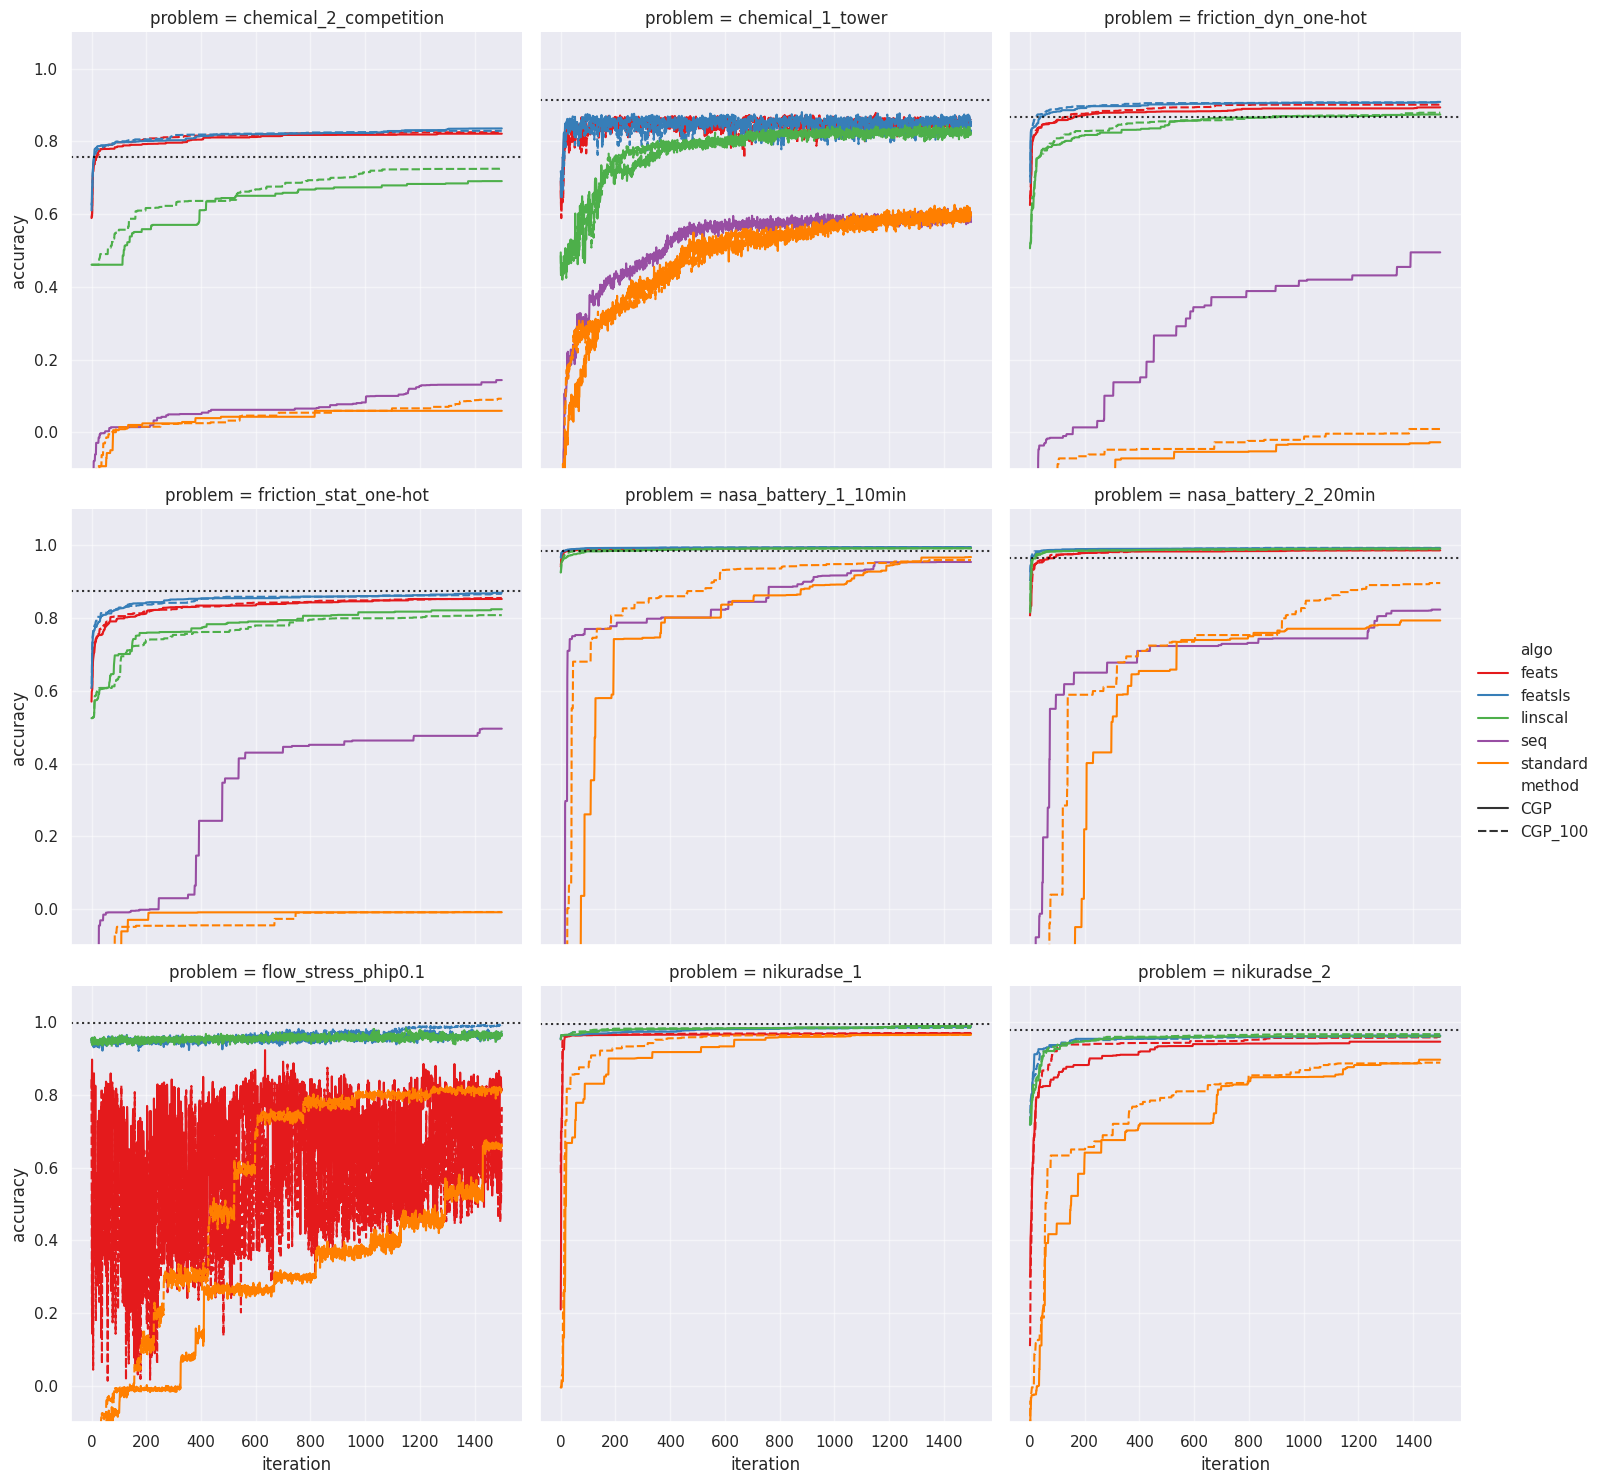

In [108]:
k = 50  # keep one point every 10 iterations
df_plot = (
    df[(df["when"] == "train") | (df["algo"] != "ridge")]
    .groupby(["problem", "algo", "method", "iteration"], as_index=False)
    .accuracy.median()
)
operon_medians = (
    final_df_and_baseline
    .query("algo == 'Operon'")
    .groupby("problem")["accuracy"]
    .median()
)

g = sns.relplot(data=df_plot, x="iteration", y="accuracy", hue="algo", col_wrap=3, style="method",
                col="problem", errorbar=None, kind="line", palette="Set1", col_order=problems)
for ax in g.axes.flat:
    problem = ax.get_title().split(" = ")[-1]  # extract problem name from facet title

    if problem in operon_medians.index:
        ax.axhline(
            y=operon_medians.loc[problem],
            linestyle=":",
            color="black",
            linewidth=1.5,
            alpha=0.8,
        )
plt.ylim(-.1, 1.1)
plt.show()

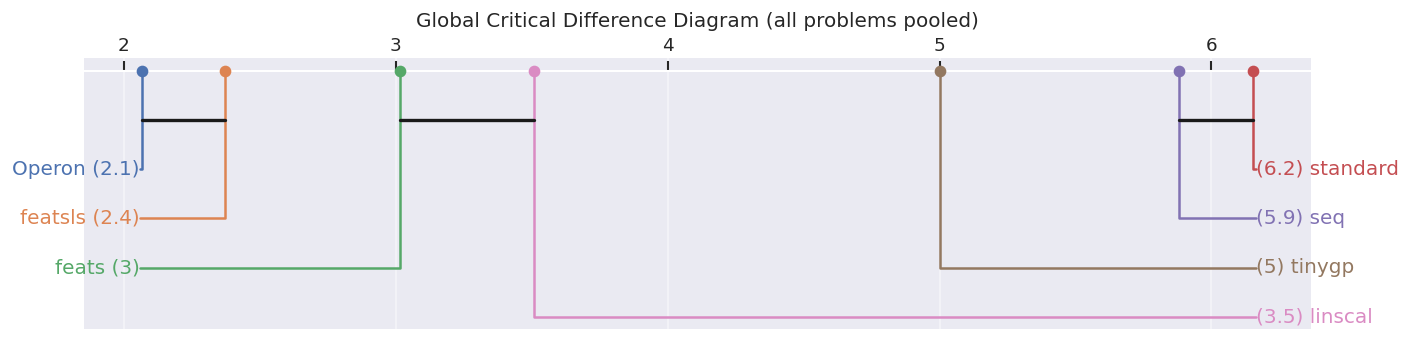

In [109]:
# -----------------------------
# 1. Copy + clean data
# -----------------------------
df = final_df_and_baseline.copy()
df = df[df["method"] != "CGP_100"]
df = df[df["algo"] != "ridge"]
df = df[["problem", "seed", "algo", "accuracy"]].copy()

# clean strings
df["algo"] = (
    df["algo"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

# enforce numeric types (important)
df["seed"] = pd.to_numeric(df["seed"], errors="raise")
df["accuracy"] = pd.to_numeric(df["accuracy"], errors="raise")

# -----------------------------
# 2. Build global block (problem + seed)
# -----------------------------
df["block"] = df["problem"].astype(str) + "_seed_" + df["seed"].astype(str)

# -----------------------------
# 3. Pivot to wide format
# -----------------------------
df_wide = df.pivot(index="block", columns="algo", values="accuracy")

# optional: drop incomplete rows (safety)
df_wide = df_wide.dropna()

# -----------------------------
# 4. Compute average ranks (MAXIMIZATION)
# -----------------------------
avg_rank = df_wide.rank(axis=1, ascending=False).mean(axis=0)

# enforce consistent ordering
avg_rank = avg_rank.sort_values()

# -----------------------------
# 5. Posthoc Friedman
# -----------------------------
test_results = sp.posthoc_conover_friedman(df_wide)

# -----------------------------
# 6. Plot single CD diagram
# -----------------------------
plt.figure(figsize=(12, 3), dpi=120)
sp.critical_difference_diagram(avg_rank, test_results)

plt.title("Global Critical Difference Diagram (all problems pooled)")
plt.tight_layout()
plt.show()

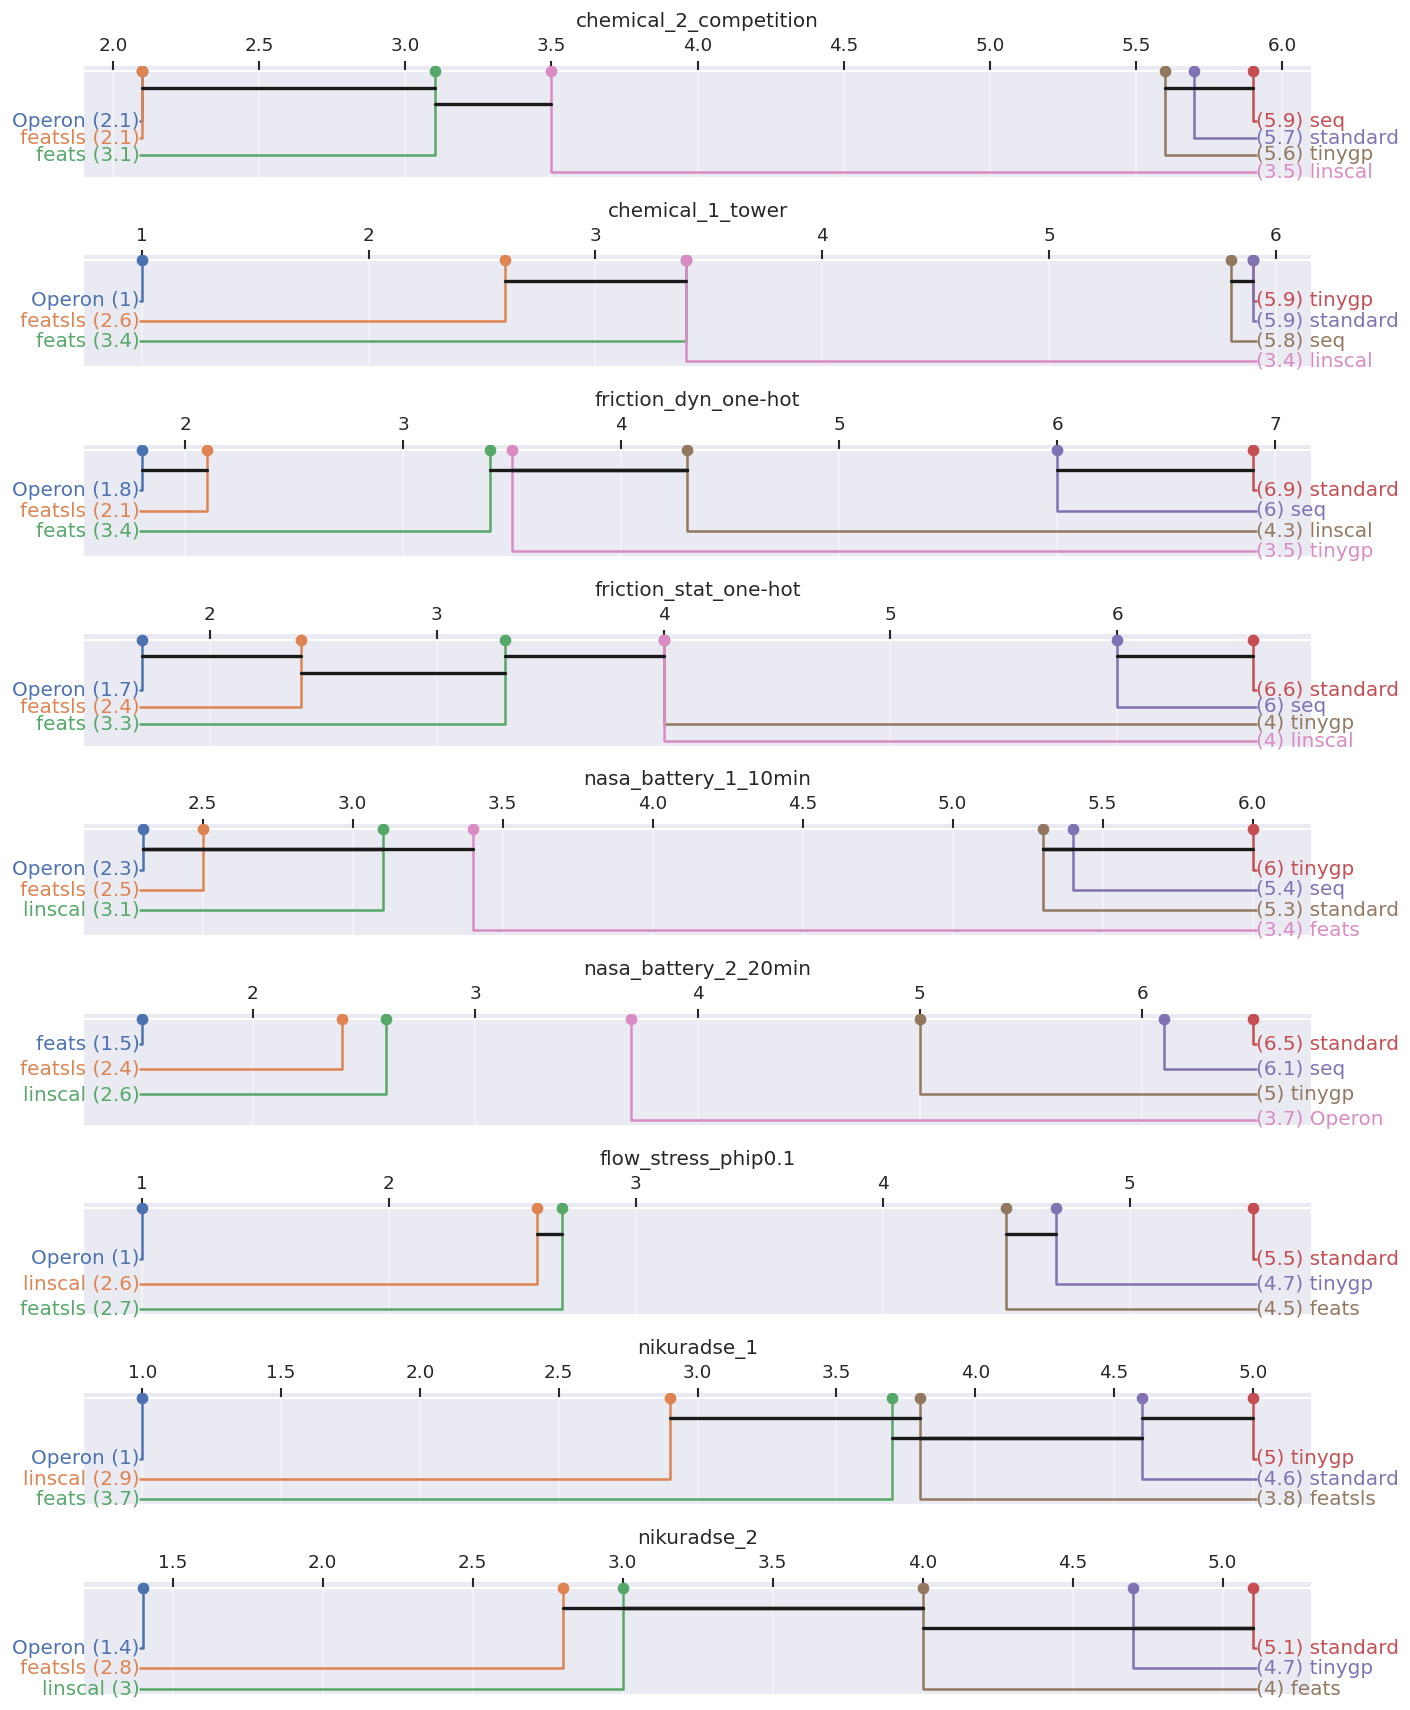

In [110]:
fig, axes = plt.subplots(
    nrows=len(problems),
    ncols=1,
    figsize=(12, 1.6 * len(problems)),
    dpi=120
)

if len(problems) == 1:
    axes = [axes]

for ax, problem in zip(axes, problems):
    df_tests = final_df_and_baseline[
        final_df_and_baseline["problem"] == problem
        ]
    df_tests = df_tests[df_tests["method"] != "CGP_100"]
    df_tests = df_tests[df_tests["algo"] != "ridge"]
    df_tests = df_tests[df_tests["seed"] < 10][["seed", "algo", "accuracy"]]

    df_tests["algo"] = (
        df_tests["algo"]
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )

    df_wide = df_tests.pivot(index="seed", columns="algo", values="accuracy")

    # average ranks (this is correct for CD diagrams)
    rank = df_wide.rank(axis=1, ascending=False)
    avg_rank = rank.mean(axis=0)

    # posthoc
    test_results = sp.posthoc_conover_friedman(df_wide)

    # draw CD diagram
    plt.sca(ax)
    sp.critical_difference_diagram(
        avg_rank,
        test_results
    )

    ax.set_title(f"{problem}")

plt.tight_layout()
plt.show()

# Graph sizes

In [111]:
genome_sizes_df_1 = pd.read_csv("genome_analysis.csv")
genome_sizes_df_1["method"] = "CGP"
genome_sizes_df_2 = pd.read_csv("genome_analysis_100.csv")
genome_sizes_df_2["method"] = "CGP_100"
genome_sizes_df = pd.concat([genome_sizes_df_1, genome_sizes_df_2], ignore_index=True)
genome_sizes_df  #.head()

,problem,seed,algo,size,method
0,chemical_2_competition,0,seq,4,CGP
1,friction_dyn_one-hot,0,seq,9,CGP
2,friction_stat_one-hot,0,seq,8,CGP
3,nasa_battery_1_10min,0,seq,16,CGP
4,nasa_battery_2_20min,0,seq,15,CGP
...,...,...,...,...,...
775,nasa_battery_2_20min,9,baseline,15,CGP_100
776,nikuradse_1,9,baseline,15,CGP_100
777,nikuradse_2,9,baseline,17,CGP_100
778,chemical_1_tower,9,baseline,10,CGP_100


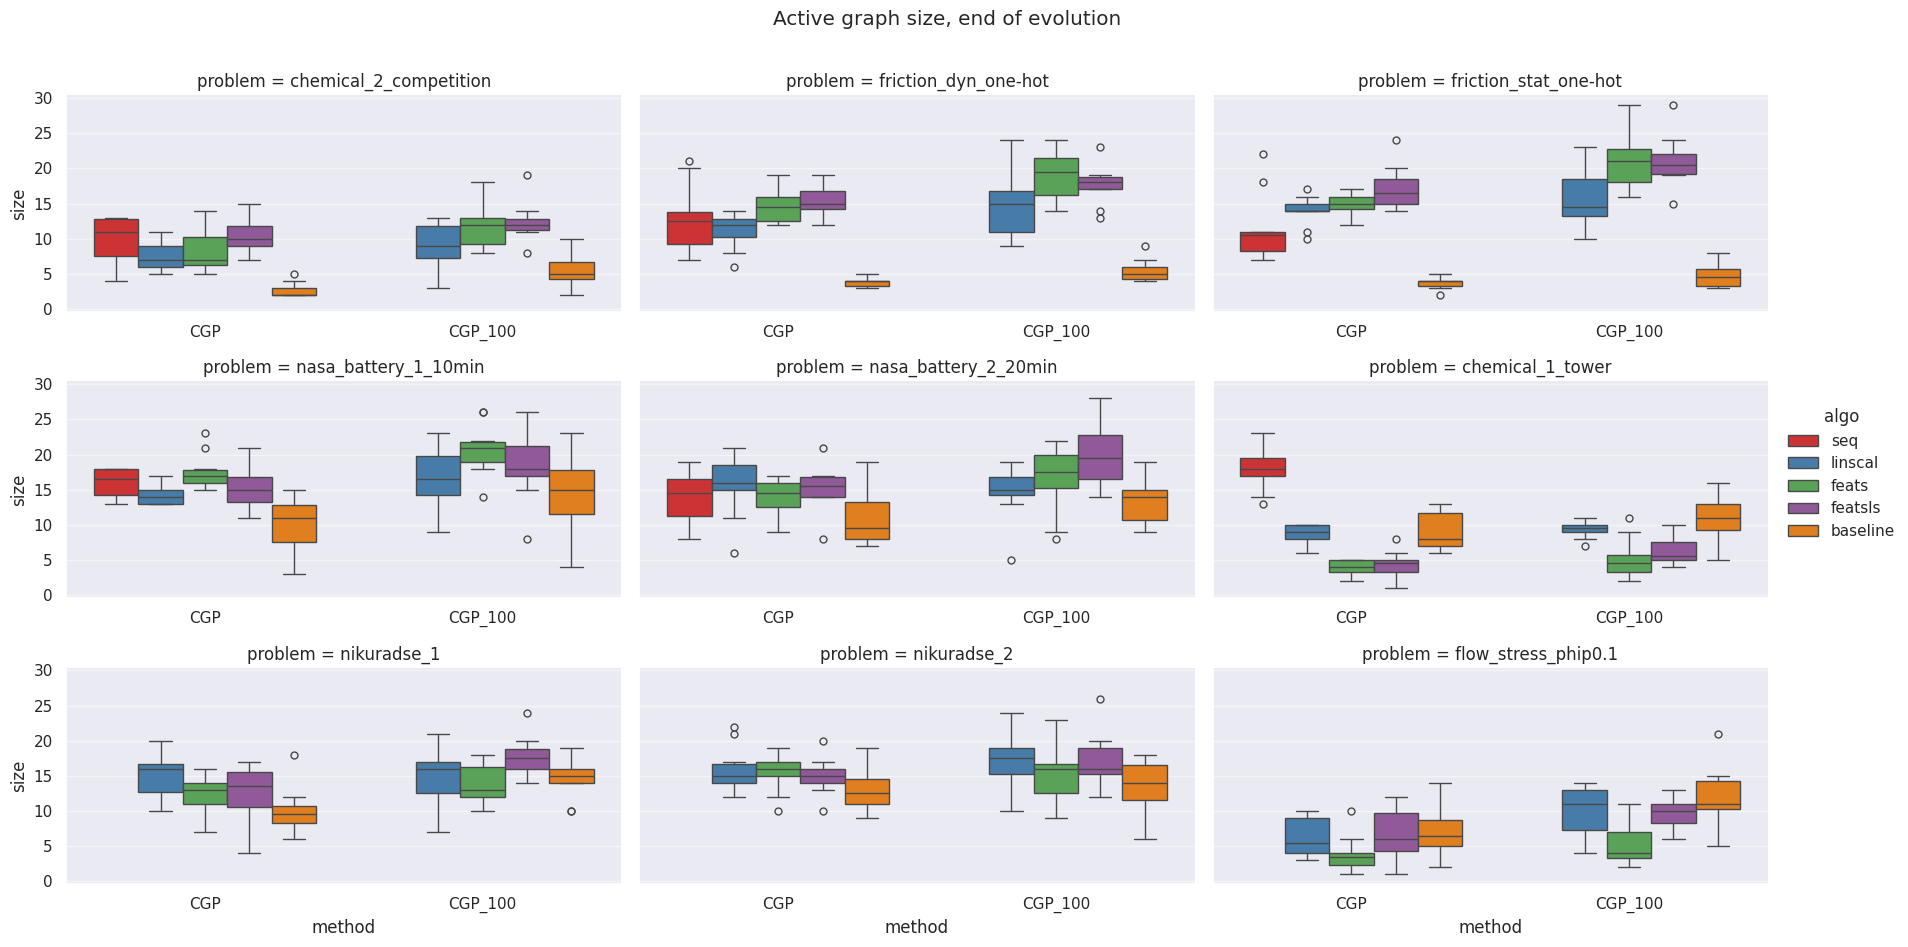

In [112]:
g = sns.catplot(x="method", y="size", hue="algo", data=genome_sizes_df, col="problem", col_wrap=3,
                kind="box", palette="Set1", height=3, aspect=2, sharex=False)
g.figure.suptitle("Active graph size, end of evolution", y=1.05)  # Add title above the plot
# plt.ylim(-.3, 1.1)
plt.show()

In [113]:
# # -----------------------------
# # 1. Copy + clean data
# # -----------------------------
# df = genome_sizes_df.copy()
# df = df[["problem", "seed", "algo", "size"]].copy()
#
# # clean strings
# df["algo"] = (
#     df["algo"]
#     .astype(str)
#     .str.replace("\n", " ", regex=False)
#     .str.strip()
# )
#
# # enforce numeric types (important)
# df["seed"] = pd.to_numeric(df["seed"], errors="raise")
# df["size"] = pd.to_numeric(df["size"], errors="raise")
#
# # -----------------------------
# # 2. Build global block (problem + seed)
# # -----------------------------
# df["block"] = df["problem"].astype(str) + "_seed_" + df["seed"].astype(str)
#
# # -----------------------------
# # 3. Pivot to wide format
# # -----------------------------
# df_wide = df.pivot(index="block", columns="algo", values="size")
#
# # optional: drop incomplete rows (safety)
# df_wide = df_wide.dropna()
#
# # -----------------------------
# # 4. Compute average ranks (MAXIMIZATION)
# # -----------------------------
# avg_rank = df_wide.rank(axis=1, ascending=True).mean(axis=0)
#
# # enforce consistent ordering
# avg_rank = avg_rank.sort_values()
#
# # -----------------------------
# # 5. Posthoc Friedman
# # -----------------------------
# test_results = sp.posthoc_conover_friedman(df_wide)
#
# # -----------------------------
# # 6. Plot single CD diagram
# # -----------------------------
# plt.figure(figsize=(12, 3), dpi=120)
# sp.critical_difference_diagram(avg_rank, test_results)
#
# plt.title("Global Critical Difference Diagram of Sizes (all problems pooled)")
# plt.tight_layout()
# plt.show()

In [114]:
# fig, axes = plt.subplots(
#     nrows=len(genome_sizes_df["problem"].unique()),
#     ncols=1,
#     figsize=(12, 1.6 * len(genome_sizes_df["problem"].unique())),
#     dpi=120
# )
#
# if len(genome_sizes_df["problem"].unique()) == 1:
#     axes = [axes]
#
# for ax, problem in zip(axes, genome_sizes_df["problem"].unique()):
#     df_tests = genome_sizes_df[
#         genome_sizes_df["problem"] == problem
#         ]
#
#     df_tests = df_tests[df_tests["seed"] < 10][["seed", "algo", "size"]]
#
#     df_tests["algo"] = (
#         df_tests["algo"]
#         .str.replace("\n", " ", regex=False)
#         .str.strip()
#     )
#
#     df_wide = df_tests.pivot(index="seed", columns="algo", values="size")
#
#     # average ranks (this is correct for CD diagrams)
#     rank = df_wide.rank(axis=1, ascending=True)
#     avg_rank = rank.mean(axis=0)
#
#     # posthoc
#     test_results = sp.posthoc_conover_friedman(df_wide)
#
#     # draw CD diagram
#     plt.sca(ax)
#     sp.critical_difference_diagram(
#         avg_rank,
#         test_results
#     )
#
#     ax.set_title(f"{problem}")
#
# plt.tight_layout()
# plt.show()

# Sensitivity of features number

In [115]:
sensitivity_dfs = []
problem = "chemical_2_competition"
for n_feats in range(2, 58, 2):
    for seed in range(30):
        for extra in ['feats', 'featsls']:
            path = f"../results/sensitivity/CGP_{extra}_{problem}_{seed}_{n_feats}"
            if n_feats == 8:
                path = path.replace("/sensitivity", "").replace("_8", "")
            if os.path.exists(f"{path}.pickle"):
                tmp_df = pd.read_csv(f"{path}.csv")
                tmp_df["seed"] = seed
                tmp_df["problem"] = problem
                tmp_df["n_features"] = n_feats
                tmp_df["algo"] = f"CGP \n {extra}"
                tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
                sensitivity_dfs.append(tmp_df)
sensitivity_df = pd.concat(sensitivity_dfs, ignore_index=True)
sensitivity_df["test_accuracy"] = sensitivity_df["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(float)
sensitivity_df.head()

,iteration,max_fitness,time,test_accuracy,seed,problem,n_features,algo,total_time
0,0,0.306892,0.000000,0.059002,0,chemical_2_competition,2,CGP \n feats,0
1,1,0.306892,1.660011,0.059002,0,chemical_2_competition,2,CGP \n feats,1
2,2,0.306892,0.858455,0.059002,0,chemical_2_competition,2,CGP \n feats,2
3,3,0.306892,0.914011,0.059002,0,chemical_2_competition,2,CGP \n feats,3
4,4,0.306892,0.949023,0.059002,0,chemical_2_competition,2,CGP \n feats,4


In [116]:
sensitivity_df1 = copy(sensitivity_df)
sensitivity_df2 = copy(sensitivity_df)
sensitivity_df1 = sensitivity_df1.rename(columns={"test_accuracy": "accuracy"})
sensitivity_df2 = sensitivity_df2.rename(columns={"max_fitness": "accuracy"})
sensitivity_df1 = sensitivity_df1.drop(columns=["max_fitness"])
sensitivity_df2 = sensitivity_df2.drop(columns=["test_accuracy"])
sensitivity_df1["when"] = "test"
sensitivity_df2["when"] = "train"
sensitivity_df = pd.concat([sensitivity_df1, sensitivity_df2], ignore_index=True)
sensitivity_df.head()

,iteration,time,accuracy,seed,problem,n_features,algo,total_time,when
0,0,0.000000,0.059002,0,chemical_2_competition,2,CGP \n feats,0,test
1,1,1.660011,0.059002,0,chemical_2_competition,2,CGP \n feats,1,test
2,2,0.858455,0.059002,0,chemical_2_competition,2,CGP \n feats,2,test
3,3,0.914011,0.059002,0,chemical_2_competition,2,CGP \n feats,3,test
4,4,0.949023,0.059002,0,chemical_2_competition,2,CGP \n feats,4,test


In [117]:
final_sensitivity_df = sensitivity_df[sensitivity_df["iteration"] == max(sensitivity_df["iteration"])].reset_index(
    drop=True)
final_sensitivity_df.head()

,iteration,time,accuracy,seed,problem,n_features,algo,total_time,when
0,1499,0.996661,0.622282,0,chemical_2_competition,2,CGP \n feats,1488,test
1,1499,0.963794,0.521470,0,chemical_2_competition,2,CGP \n featsls,1407,test
2,1499,1.070991,0.768297,1,chemical_2_competition,2,CGP \n feats,1691,test
3,1499,1.105551,0.757006,1,chemical_2_competition,2,CGP \n featsls,1708,test
4,1499,1.098661,0.656548,2,chemical_2_competition,2,CGP \n feats,1830,test


In [136]:
sensitivity_sizes_df = pd.read_csv("genome_analysis_sensitivity.csv")
base_size = genome_sizes_df[
    (genome_sizes_df["problem"] == "chemical_2_competition") &
    (genome_sizes_df["algo"].isin(["feats", "featsls"]))
    ]
base_size = base_size.drop(columns=["method"], inplace=False)
base_size["n_features"] = 8
sensitivity_sizes_df = pd.concat([sensitivity_sizes_df, base_size], ignore_index=True)
sensitivity_sizes_df.head()

,problem,seed,algo,size,n_features
0,chemical_2_competition,0,feats,7,2
1,chemical_2_competition,0,feats,10,4
2,chemical_2_competition,0,feats,14,6
3,chemical_2_competition,0,feats,7,10
4,chemical_2_competition,0,feats,9,12


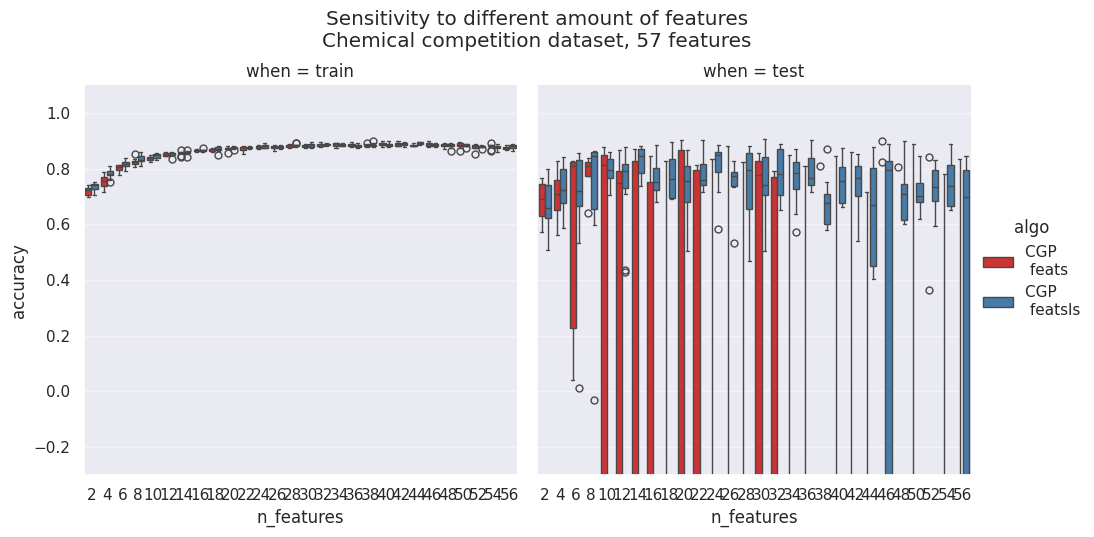

In [118]:
g = sns.catplot(x="n_features",
                y="accuracy",
                hue="algo",
                data=final_sensitivity_df,
                # col="problem",
                col_order=["train", "test"],
                col="when",
                kind="box", palette="Set1", sharex=True)  #height=3, aspect=2,
g.figure.suptitle("Sensitivity to different amount of features\nChemical competition dataset, 57 features", y=1.07)
plt.ylim(-.3, 1.1)
plt.show()

In [119]:
cgp_medians = (
    final_df_and_baseline[
        (final_df_and_baseline["method"] == "CGP") &
        (final_df_and_baseline["algo"] == "standard")
        ]
    .groupby("problem")["accuracy"]
    .median()
)

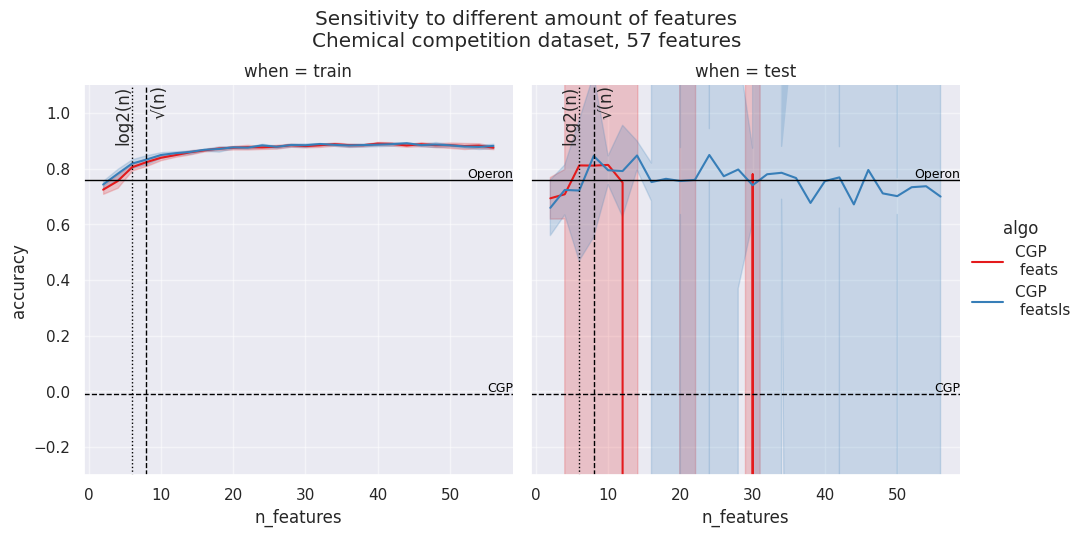

In [120]:
g = sns.relplot(
    data=final_sensitivity_df,
    x="n_features",
    y="accuracy",
    hue="algo",
    # col="problem",
    col="when",
    col_order=["train", "test"],
    kind="line",
    estimator="median",  # plot the mean
    errorbar="sd",  # shaded ±1 standard deviation
    # or errorbar=("ci", 95) for 95% confidence interval
    palette="Set1",
)
for ax in g.axes.flat:
    ax.axvline(x=6, linestyle=":", color="black", linewidth=1)
    ax.axvline(x=8, linestyle="--", color="black", linewidth=1)
    ax.axhline(y=operon_medians["chemical_2_competition"], color="black", linewidth=1)
    ax.axhline(y=cgp_medians["chemical_2_competition"], linestyle="--", color="black", linewidth=1)
    x_max = ax.get_xlim()[1]
    ax.text(
        x_max,
        operon_medians["chemical_2_competition"],
        "Operon",
        va="bottom",
        ha="right",
        fontsize=9,
        color="black",
    )
    ax.text(
        x_max,
        cgp_medians["chemical_2_competition"],
        "CGP",
        va="bottom",
        ha="right",
        fontsize=9,
        color="black",
    )
    ax.annotate(
        "log2(n)",
        xy=(6, 1),
        xytext=(3.5, 1.1),
        textcoords="data",
        rotation=90,
        va="top"
    )
    ax.annotate(
        "√(n)",
        xy=(8, 1),
        xytext=(8.5, 1.1),
        textcoords="data",
        rotation=90,
        va="top"
    )

g.figure.suptitle("Sensitivity to different amount of features\nChemical competition dataset, 57 features", y=1.07)
g.set(ylim=(-0.3, 1.1))
plt.show()

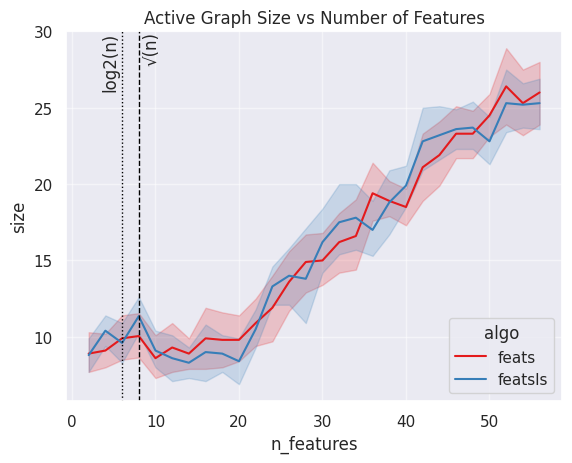

In [137]:
ax = sns.lineplot(sensitivity_sizes_df, x="n_features", y="size", hue="algo", palette="Set1")
ax.axvline(x=6, linestyle=":", color="black", linewidth=1)
ax.axvline(x=8, linestyle="--", color="black", linewidth=1)
ax.annotate(
    "log2(n)",
    xy=(6, 30),
    xytext=(3.5, 30),
    textcoords="data",
    rotation=90,
    va="top"
)
ax.annotate(
    "√(n)",
    xy=(8, 30),
    xytext=(8.5, 30),
    textcoords="data",
    rotation=90,
    va="top"
)
ax.set_title("Active Graph Size vs Number of Features")
plt.show()